What are the most demanded skills for the top 3 most popular data roles?

Methodology

1.Clean-up skill column
2.Calculate skill count based on job_title_short
3.Calculate skill percentage
4.Plot final findings

In [ ]:
#importing Libraries

import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

from adjustText import adjust_text

#Loading data
dataset = load_dataset ('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])


def clean_list(skill_list):
 if pd.notna(skill_list):
    return ast.literal_eval(skill_list)

df['job_skills']= df['job_skills'].apply(clean_list)

c:\Users\hp\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/lukebarousse/data_jobs/resolve/ed776e5a0a8c40ea9d5efbd800772ae52e140f3e/data_jobs.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\hp\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Fri Apr 17 15:59:23 2026).


In [ ]:
df_US = df[df['job_country'] == 'United States']

In [ ]:

df_skills = df_US.explode('job_skills')

df_skills[['job_title_short','job_skills']]

,job_title_short,job_skills
0,Senior Data Engineer,NaN
3,Data Engineer,python
3,Data Engineer,c++
3,Data Engineer,java
3,Data Engineer,matlab
...,...,...
785692,Data Scientist,r
785703,Data Analyst,NaN
785705,Data Analyst,sql
785705,Data Analyst,python


In [ ]:
skills_count = df_skills.groupby(['job_title_short','job_skills']).size()

skills_count = skills_count.reset_index(name = 'skill_count')

skills_count.sort_values(by = 'skill_count', ascending = False, inplace = True)

skills_count

,job_title_short,job_skills,skill_count
886,Data Scientist,python,42379
472,Data Analyst,sql,34452
921,Data Scientist,sql,30034
351,Data Analyst,excel,27519
890,Data Scientist,r,26022
...,...,...,...
1350,Senior Data Engineer,elixir,1
1819,Software Engineer,sass,1
487,Data Analyst,theano,1
1847,Software Engineer,theano,1


In [ ]:
job_titles = skills_count['job_title_short'].unique().tolist()

job_titles = sorted (job_titles[:3])

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

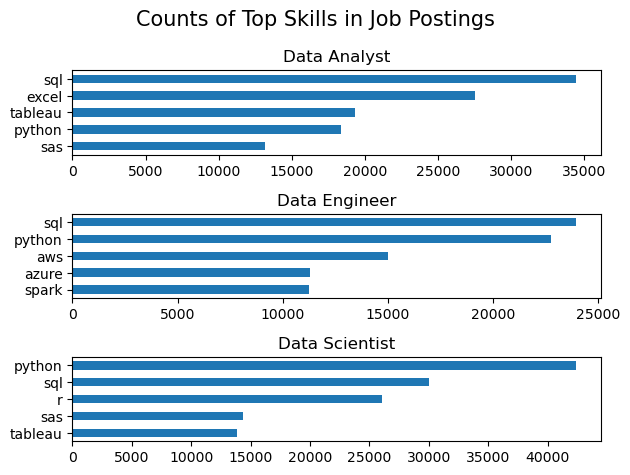

In [ ]:
fig,ax =plt.subplots(len(job_titles),1)

for i , job_title in enumerate(job_titles):
     df_plot = skills_count[skills_count['job_title_short'] == job_title].head(5)
     df_plot.plot(kind = 'barh', x= 'job_skills', y= 'skill_count', ax=ax[i], title = job_title)
     ax[i].invert_yaxis()
     ax[i] .set_ylabel('')
     ax[i].legend().set_visible(False)
  

     fig.tight_layout()
     fig.suptitle('Counts of Top Skills in Job Postings',fontsize = 15)

In [ ]:
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name='jobs_total')

In [ ]:
df_skills_perc = pd.merge (skills_count, df_job_title_count , how = 'left', on='job_title_short')

df_skills_perc['skill_perc']= 100 * df_skills_perc['skill_count']/df_skills_perc['jobs_total']

df_skills_perc

,job_title_short,job_skills,skill_count,jobs_total,skill_perc
0,Data Scientist,python,42379,58830,72.036376
1,Data Analyst,sql,34452,67816,50.802171
2,Data Scientist,sql,30034,58830,51.052184
3,Data Analyst,excel,27519,67816,40.578919
4,Data Scientist,r,26022,58830,44.232534
...,...,...,...,...,...
1865,Senior Data Engineer,elixir,1,9289,0.010765
1866,Software Engineer,sass,1,1814,0.055127
1867,Data Analyst,theano,1,67816,0.001475
1868,Software Engineer,theano,1,1814,0.055127


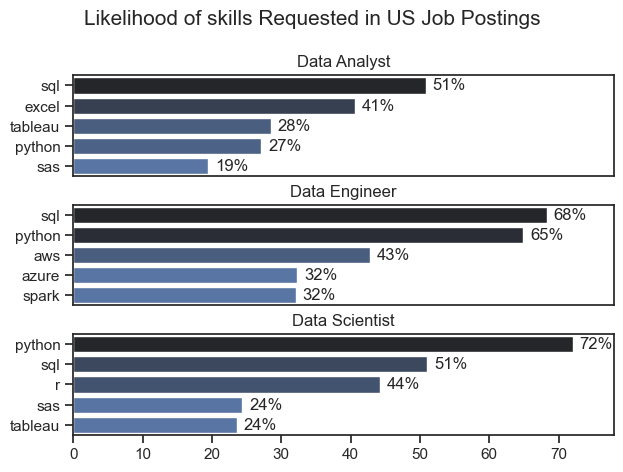

In [ ]:
fig,ax =plt.subplots(len(job_titles),1)

for i , job_title in enumerate(job_titles):
     df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
     
     sns.barplot(data= df_plot, x = 'skill_perc',
                 y = 'job_skills', ax=ax[i],hue = 'skill_perc', palette = 'dark:b_r')
     sns.set_theme(style = 'ticks')
    
     ax[i].set_title(job_title)
     ax[i].set_ylabel('')
     ax[i].set_xlabel('')
     ax[i].get_legend().remove()
     ax[i].set_xlim(0,78)
  
     for n, v in enumerate (df_plot['skill_perc']):
        ax[i].text(v + 1, n, f'{ v:.0f}%', va = 'center')

     if i!=len(job_titles) - 1:  
          ax[i].set_xticks([])
     
     fig.tight_layout(h_pad=0.5)
     fig.suptitle('Likelihood of skills Requested in US Job Postings',fontsize = 15)

     plt.show()